# XOPT - INTERPRETABLE METAHEURISTICS FOR COMBINATORIAL OPTIMIZATION

## HIERARCHICAL CLUSTERING

Graph analysis and extraction of the connected component of the best solution. The bipartite graph is composed of two independent vertex sets:

    1. First set represents the solution nodes;
    2. Second set represents the facility (resource) nodes.

### SETTING THE ENVIRONMENT

Importing the libraries:

In [1]:
import sys

from pathlib import Path

parent_path = Path().resolve().parent.parent

if str(parent_path) not in sys.path:
    sys.path.insert(0, str(parent_path))

In [2]:
import agnes
import random
import pymedian

import numpy as np
import matplotlib.pyplot as plt

This cell locates the "instances" folder in the project root and counts how many p-median instance files exist:

In [3]:
ROOT          = Path.cwd().resolve().parent.parent
INSTANCES_DIR = ROOT / "instances"

if not INSTANCES_DIR.exists():
    raise FileNotFoundError(f"Instances folder not found: {INSTANCES_DIR}")

print(f"Total number of p-median instances: {len(list(INSTANCES_DIR.glob('pmed[0-9]*.txt')))}")

Total number of p-median instances: 40


### APPLYING

We selected a few classic p-median instances and recorded the results obtained:

In [4]:
instance      = "pmed11.txt"
instance_path = str(INSTANCES_DIR / instance)

summary, details = pymedian.solve_pmedian(instance_path,
                                          restarts=8   ,
                                          max_iter=25  ,
                                          factor  =2   ,
                                          details_format='indices')


print(f"Instance {summary['instance'][:-4]} ({summary['p']}-{summary['n']})")

print()
print(f"  K-Medoids ({summary['kmedoids_cost']}): {summary['medoids'          ][:10]}")
print(f"  TSPMED    ({summary['tspmed_cost'  ]}): {summary['tspmed_facilities'][:10]}")

print()
print(f"Obs.: Distinct solutions recorded in long term memory is {summary['long_term_mem']}!")

Instance /home/rei-luisinho/xopt/instances/pmed11 (5-300)

  K-Medoids (7696.0): [98, 201, 167, 24, 31]
  TSPMED    (7696.0): [98, 201, 167, 24, 31]

Obs.: Distinct solutions recorded in long term memory is 784!


### OBTAINING THE CONNECTED COMPONENT SUBGRAPH

A disjoint-set (Union–Find) data structure is employed to process adjacency lists by **merging elements that share connectivity.**

- The partitioned elements correspond to vertices in the first independent set of the bipartite graph.
- Each resulting partition defines a connected component of the graph.

**Algorithm description:**

1. All resources are initially considered as singleton disjoint sets.
2. For each adjacency list that associates multiple resources with a given vertex, the associations are examined.
3. Resources that co-occur within the same adjacency list are unified into a single disjoint set.

Reading the bipartite graph:

In [5]:
solutions = details["long_term_memory"]

bigraph = agnes.BiGraph()

bigraph.N = len(solutions)
bigraph.L = summary["n"]

bigraph.adj_list = [
    solution["facilities"]
    for solution in solutions
]


print(f"Characteristics of the bipartite graph: {str(bigraph)}")

Characteristics of the bipartite graph: N_784_L_300


Merging associated resources in the bipartite graph:

In [6]:
unionfind = agnes.UnionFind(bigraph.L)

for adj in bigraph:
    if len(adj) < 2:
        continue

    u = adj[0]
    for v in adj[1:]:
        unionfind.union(u, v)

In [7]:
random_idx = random.randint(0, bigraph.N - 1)
adjacency  = bigraph.adj_list[random_idx]


print(f"Random adjacency list at index {random_idx}.")
print()

print("Union-Find roots for each vertex:")

first_root      = None
in_same_cluster = True

for vertex in adjacency:
    root = unionfind.find(vertex)

    if first_root is None:
        first_root = root
    elif root != first_root:
        in_same_cluster = False

    print(f"  Vertex {vertex:3d} → root {root}")

print()
print(f"All vertices in same cluster: {in_same_cluster}")

Random adjacency list at index 742.

Union-Find roots for each vertex:
  Vertex  13 → root 3
  Vertex  23 → root 3
  Vertex  67 → root 3
  Vertex  78 → root 3
  Vertex 145 → root 3

All vertices in same cluster: True


Extracting connected components and counting vertices:

In [8]:
components = {}

for solution, (first, *_) in enumerate(bigraph):
    root = unionfind.find(first)

    if root not in components:
        components[root] = []

    components[root].append(solution)


print(f"Total connected components is {len(components)}!")

Total connected components is 1!


The analysis revealed that the bipartite graph contains a single connected component. This result implies that all vertices in the considered partition are indirectly connected through shared resources. In other words, there exists a path between any pair of vertices in the graph. Consequently:

- The structure is fully connected at the component level.
- **No natural fragmentation or isolated substructures are present.**
- Any clustering performed afterward will reflect internal structural variations rather than separations caused by disconnected subgraphs.

From a graph-theoretic perspective, the absence of multiple connected components indicates that the solution induces a globally cohesive structure.

### HIERARCHICAL CLUSTERING

Finding the index of the best solution:

In [9]:
solutions = details["long_term_memory"]

best_idx, best_solution = min(
    enumerate(solutions),
    key=lambda x: x[1]["cost"]
)

best_cost = best_solution["cost"      ]
best_sol  = best_solution["facilities"]


print(f"Best solution found at index {best_idx} with cost {best_cost}.")

Best solution found at index 451 with cost 7696.0.


Hierarchical clustering is performed using a threshold of 3.0, resulting in clusters whose set-intersection similarity corresponds to at least three facilities selected in the solution:

In [10]:
THRESHOLD = 2.0


dendrogram_data = agnes.agnes(
    bigraph, thresh=THRESHOLD
)

print(f"Number of dendrograms (threshold {THRESHOLD}): {len(dendrogram_data)}")

Number of dendrograms (threshold 2.0): 33


Showing the linkage with the best facility:

In [11]:
best_linkage = agnes.vertex2linkage(
    best_idx, dendrogram_data
)


print("Linkage rows associated with best solution:", dendrogram_data[best_linkage].shape[0])

Linkage rows associated with best solution: 21


<Figure size 1200x600 with 0 Axes>

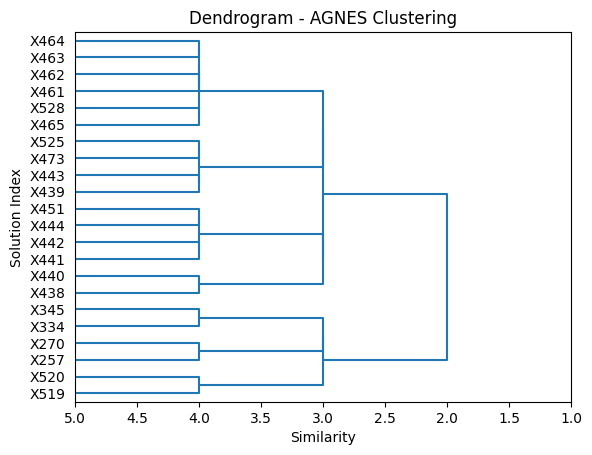

In [12]:
plt.figure(figsize=(12, 6))

agnes.dendrogram(
    dendrogram_data[best_linkage], bigraph.N, bigraph.L
)

plt.title ("Dendrogram - AGNES Clustering")
plt.xlabel("Similarity"    )
plt.ylabel("Solution Index")

plt.show()

Analyzing the solutions within the hierarchical linkage structure:

In [13]:
indices = dendrogram_data[best_linkage][:, :2].ravel()
indices = indices[indices < bigraph.N]

print(indices)

[257. 270. 334. 345. 438. 440. 439. 443. 441. 442. 444. 451. 461. 462.
 463. 464. 465. 528. 473. 525. 519. 520.]


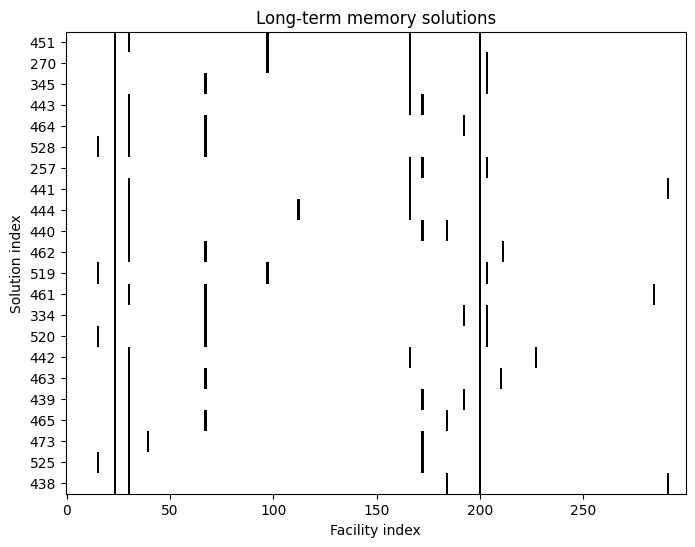

In [14]:
def indices_to_binary_vector(indices, n):
    vector = np.zeros(n, dtype=np.int8)

    vector[list(indices)] = 1

    return vector


rows            = indices.astype(int )
ytick_positions = np.arange(len(rows))

matrix = np.vstack(
    [
        indices_to_binary_vector(
            sol["facilities"], bigraph.L
        )
        for sol in details["long_term_memory"]
    ]
)
costs  = np.array(
    [
        sol["cost"]
        for sol in details["long_term_memory"]
    ],
    dtype=float
)

matrix = matrix[rows]
costs  = costs [rows]

order  = np.argsort(costs)
matrix = matrix[order]
costs  = costs [order]
rows   = rows  [order]


plt.figure(figsize=(8, 6))

plt.imshow(matrix,
           cmap         ="binary" ,
           aspect       ="auto"   ,
           interpolation="nearest")

plt.yticks(ytick_positions, rows)

plt.xlabel("Facility index")
plt.ylabel("Solution index")
plt.title ("Long-term memory solutions")

plt.show()

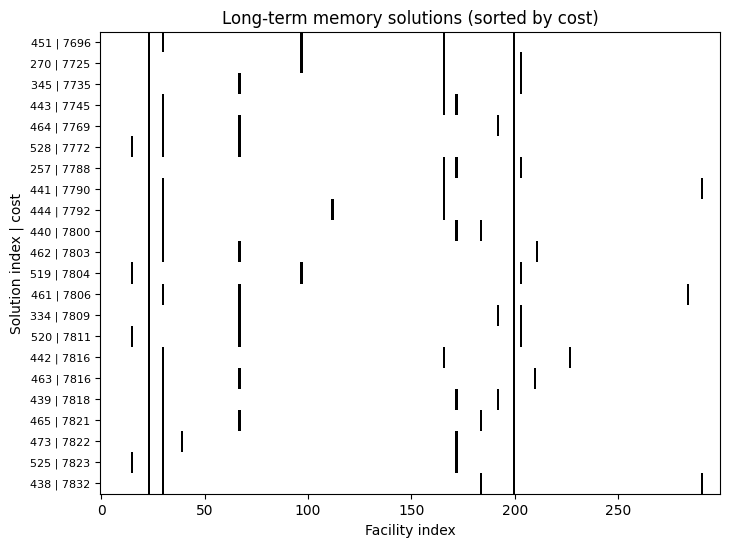

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.imshow(matrix,
          cmap         ="binary" ,
          aspect       ="auto"   ,
          interpolation="nearest")

ax.set_yticks     (ytick_positions)
ax.set_yticklabels([f"{r} | {int(c)}" for r, c in zip(rows, costs)], fontsize=8)

ax.set_xlabel("Facility index"       )
ax.set_ylabel("Solution index | cost")
ax.set_title ("Long-term memory solutions (sorted by cost)")

plt.show()